# Scraping geospatial data 

## Fetching OpenStreetMap data using overpass

### Find all the resturatnts within a certain given distance from KFUPM

In [1]:
# !pip install overpass
import overpass

api = overpass.API()

# Define the location for the query
location = (26.307, 50.1459) # KFUPM

# Define the raidus of the area for the query in meters
distance = 3000

# Create the Overpass query
overpass_query = f"""
node["amenity"="restaurant"](around:{distance},{location[0]},{location[1]});
out;
"""

restaurants = api.get(overpass_query)

In [2]:
restaurants

{"features": [{"geometry": {"coordinates": [50.128772, 26.308197], "type": "Point"}, "id": 440633807, "properties": {"amenity": "restaurant", "name": "Dining Hall"}, "type": "Feature"}, {"geometry": {"coordinates": [50.142863, 26.317956], "type": "Point"}, "id": 1236774055, "properties": {"amenity": "restaurant", "cuisine": "regional", "name": "Kudu"}, "type": "Feature"}, {"geometry": {"coordinates": [50.121013, 26.302264], "type": "Point"}, "id": 2141533774, "properties": {"amenity": "restaurant", "cuisine": "american", "name": "Rolling Hills Golf Course Clubhouse"}, "type": "Feature"}, {"geometry": {"coordinates": [50.129886, 26.303908], "type": "Point"}, "id": 2141543565, "properties": {"amenity": "restaurant", "cuisine": "asian", "name": "Tandori House Restaurant"}, "type": "Feature"}, {"geometry": {"coordinates": [50.174833, 26.304342], "type": "Point"}, "id": 4086009532, "properties": {"addr:city": "Khobar", "addr:housenumber": "144", "addr:postcode": "133", "addr:street": "Princ

### Print the list of found resturants

In [3]:
print("List of Restaurants:")
restaurant_locations = []
for feature in restaurants["features"]:
    # Extract restaurant details
    name = feature["properties"].get("name", "Unnamed")
    lon, lat = feature["geometry"]["coordinates"]
    restaurant_locations.append((name, lat, lon))
    print(f"- {name}: Latitude: {lat}, Longitude: {lon}")

List of Restaurants:
- Dining Hall: Latitude: 26.308197, Longitude: 50.128772
- Kudu: Latitude: 26.317956, Longitude: 50.142863
- Rolling Hills Golf Course Clubhouse: Latitude: 26.302264, Longitude: 50.121013
- Tandori House Restaurant: Latitude: 26.303908, Longitude: 50.129886
- Indian Restaurant: Latitude: 26.304342, Longitude: 50.174833
- Kudu: Latitude: 26.323301, Longitude: 50.164726
- Petit France: Latitude: 26.309157, Longitude: 50.175393
- Vapiano: Latitude: 26.307954, Longitude: 50.169674
- Unnamed: Latitude: 26.307482, Longitude: 50.168859
- Unnamed: Latitude: 26.310136, Longitude: 50.169166
- Applebee's: Latitude: 26.310388, Longitude: 50.168732
- Unnamed: Latitude: 26.310349, Longitude: 50.169112
- Ocean Basket: Latitude: 26.310373, Longitude: 50.168997
- Unnamed: Latitude: 26.309904, Longitude: 50.16914
- Dining Hall: Latitude: 26.308197, Longitude: 50.128772
- Kudu: Latitude: 26.317956, Longitude: 50.142863
- Rolling Hills Golf Course Clubhouse: Latitude: 26.302264, Longi

### Visualize the locations on a map

In [ ]:
# Create a folium map centered at KFUPM
#!pip install folium
import folium
from IPython.display import display

m = folium.Map(location=location, zoom_start=13)

# Add markers for each restaurant
for name, lat, lon in restaurant_locations:
    folium.Marker(
        location=[lat, lon],
        popup=name,
        icon=folium.Icon(color="red", icon="cutlery", prefix="fa"),
    ).add_to(m)

# Display the map
m

### Getting data using OverPass QL

📝 **Note:**  You can compile your own dataset using the Overpass QL language that runs on [Overpass turbo](https://overpass-turbo.eu/). You can use this query language to mine OpenStreetMaps data, filter it, and get it ready to be used by osmnx or any library that parses .osm files. Below is a quick review about using Overpass API, which is the official API for reading data from OpenStreetMap servers. All the online routing services and software use it. Additionally, we will usually use Nominatim to do geocoding/geo-decoding; translating addresses to/from (latitude-longitude).

⚠️ **Warning:** Also be aware of the fact that most of the time if you are building a dataset over a very big area in the map, the graph parsed from the data by osmnx won’t be complete, even though there are physically feasible routes that could make the graph complete and connect all the nodes. This deficiency is usually because of the incomplete relations and data of osm.

### Getting data using Overpass turbo’s Wizard

Fire up [Overpass turbo](https://overpass-turbo.eu/) and run these scripts and export it as .osm files.

### Getting data using Overpass turbo’s Wizard

<a href="https://overpass-turbo.eu/">Overpass turbo</a>’s Wizard provides an easy way to auto-generate Overpass QL queries. Wizard syntax is similar to that of a search engine. An example of Wizard syntax is amenity=hospital that generates an Overpass QL query to find all the hospitals in a certain region of interest. Hospital locations will be visualized on the map and can be downloaded/copied using the “Export” button. The data can be exported as GeoJSON, GPX, KML, raw OSM data, or raw data directly from Overpass API. You can then use osmnx to read .osm files with osmnx.graph_from_xml.

***

## Fetching OpenStreetMap data using osmnx

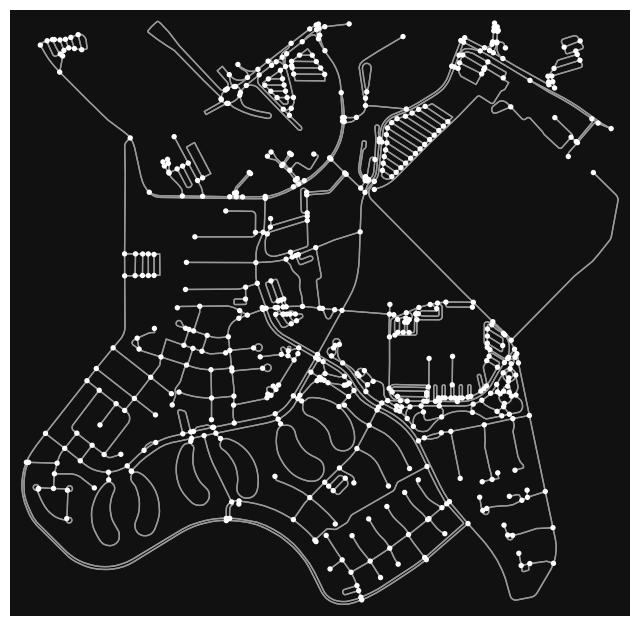

In [6]:
# !pip install osmnx

import osmnx as ox
import matplotlib.pyplot as plt


place_name = "KFUPM, Dahran, Saudi Arabia"
distance = 1000  # in meters

# fetch OSM street network (drive, walk, private, etc.) from the location
graph = ox.graph_from_address(place_name, dist=distance, network_type='walk')
fig, ax = ox.plot_graph(graph)

#### Edges and Node

We can extract the nodes and edges of the graph as separate structures.

In [7]:
nodes, edges = ox.graph_to_gdfs(graph)
nodes.head(5)

,y,x,street_count,highway,geometry
osmid,,,,,
287308533,26.308472,50.139611,3,NaN,POINT (50.13961 26.30847)
287309367,26.305740,50.142561,3,NaN,POINT (50.14256 26.30574)
287561129,26.306014,50.158347,3,NaN,POINT (50.15835 26.30601)
287561134,26.307432,50.155683,3,NaN,POINT (50.15568 26.30743)
433561654,26.308555,50.153503,4,NaN,POINT (50.1535 26.30855)


In [8]:
edges.head(5)

osmid   highway  oneway reversed      length  \
u         v           key                                                      
287308533 10056098354 0    1098276294   service   False    False   26.919558   
          6582820940  0    1376726560  tertiary   False     True  109.155120   
287309367 2380677457  0      26237372  tertiary   False    False  385.720855   
          6582820940  0    1376726560  tertiary   False    False  316.370524   
          6578561613  0    1376726560  tertiary   False     True  190.884431   

                                                                    geometry  \
u         v           key                                                      
287308533 10056098354 0    LINESTRING (50.13961 26.30847, 50.13971 26.308...   
          6582820940  0    LINESTRING (50.13961 26.30847, 50.13979 26.308...   
287309367 2380677457  0    LINESTRING (50.14256 26.30574, 50.14249 26.305...   
          6582820940  0    LINESTRING (50.14256 26.30574, 50.1425 26.3058...   
          6578561613  0    LINESTRING (50.14256 26.30574, 50.14262 26.305...   

                          maxspeed                   name service junction  \
u         v           key                                                    
287308533 10056098354 0        NaN                    NaN     NaN      NaN   
          6582820940  0         50     Academic Belt Road     NaN      NaN   
287309367 2380677457  0        NaN  Dr Bakr Bin Bakr Road     NaN      NaN   
          6582820940  0         50     Academic Belt Road     NaN      NaN   
          6578561613  0         50     Academic Belt Road     NaN      NaN   

                          tunnel access  
u         v           key                
287308533 10056098354 0      NaN    NaN  
          6582820940  0      NaN    NaN  
287309367 2380677457  0      NaN    NaN  
          6582820940  0      NaN    NaN  
          6578561613  0      NaN    NaN

We can further drill down to examine each individual node or edge.

In [9]:
# Rendering the 2nd node
list(graph.nodes(data=True))[1]

(287309367, {'y': 26.3057396, 'x': 50.1425614, 'street_count': 3})

In [10]:
# Rendering the 1st edge
list(graph.edges(data=True))[0]

(287308533,
 10056098354,
 {'osmid': 1098276294,
  'highway': 'service',
  'oneway': False,
  'reversed': False,
  'length': np.float64(26.91955804032482),
  'geometry': <LINESTRING (50.14 26.308, 50.14 26.309, 50.14 26.309)>})

### Street Types
Street types can also be retrieved for the graph:

In [11]:
print(edges['highway'].value_counts())

highway
service          904
residential      254
tertiary         210
footway          192
pedestrian        82
unclassified      50
tertiary_link      2
Name: count, dtype: int64


### Calculating Network Statistics

In [12]:
ox.basic_stats(graph)

{'n': 593,
 'm': 1694,
 'k_avg': 5.713322091062395,
 'edge_length_total': 121460.70405735345,
 'edge_length_avg': 71.70053368202683,
 'streets_per_node_avg': 2.8853288364249576,
 'streets_per_node_counts': {0: 0, 1: 68, 2: 0, 3: 459, 4: 65, 5: 0, 6: 1},
 'streets_per_node_proportions': {0: 0.0,
  1: 0.11467116357504216,
  2: 0.0,
  3: 0.7740303541315345,
  4: 0.10961214165261383,
  5: 0.0,
  6: 0.0016863406408094434},
 'intersection_count': 525,
 'street_length_total': 60730.35202867664,
 'street_segment_count': 847,
 'street_length_avg': 71.70053368202673,
 'circuity_avg': 1.2058694871360855,
 'self_loop_proportion': 0.018890200708382526}

*** 

### Visualize points of interest

In [13]:
import folium

center=(26.3071, 50.1459) # KFUPM
source_point = (26.3032, 50.1594) # Dhahran Techno Valley
destination_point = (26.3142, 50.1476) # KFUPM Mall

m = folium.Map(location=center, zoom_start=15, zoom_control=False, scrollWheelZoom=False, dragging=False)
folium.Marker(location=source_point,icon=folium.Icon(color='red',icon='university', prefix='fa')).add_to(m)
folium.Marker(location=center,icon=folium.Icon(color='blue',icon='graduation-cap', prefix='fa')).add_to(m)
folium.Marker(location=destination_point,icon=folium.Icon(color='green',icon='store', prefix='fa')).add_to(m)

m

### Finding the shortest path

Let’s find the shortest path between Dhahran Techno Valley to KFUPM Mall. To calculate this shortest path, we first need to find the closest nodes on the network to our starting and ending locations.

In [14]:
import geopandas

X = [source_point[1], destination_point[1]]
Y = [source_point[0], destination_point[0]]
closest_nodes = ox.distance.nearest_nodes(graph,X,Y)

# Get the rows from the Node GeoDataFrame
closest_rows = nodes.loc[closest_nodes]

# Put the two nodes into a GeoDataFrame
od_nodes = geopandas.GeoDataFrame(closest_rows, geometry='geometry', crs=nodes.crs)
od_nodes

,y,x,street_count,highway,geometry
osmid,,,,,
2380687168,26.304721,50.157762,1,NaN,POINT (50.15776 26.30472)
6582857365,26.309090,50.148741,4,NaN,POINT (50.14874 26.30909)


Let’s find and plot the shortest route now!

In [15]:
import networkx

shortest_route = networkx.shortest_path(G=graph,source=closest_nodes[0],target=closest_nodes[1], weight='length')
print(shortest_route)

[np.int64(2380687168), 2380686994, 6577799169, 6578557735, 6577764261, 1465207251, 2380680808, 2380680823, 2380680825, 12747800040, 12747800047, 12747800048, 1465207269, 6578561631, 829246395, 6582857364, np.int64(6582857365)]


### Visualize the shortest path

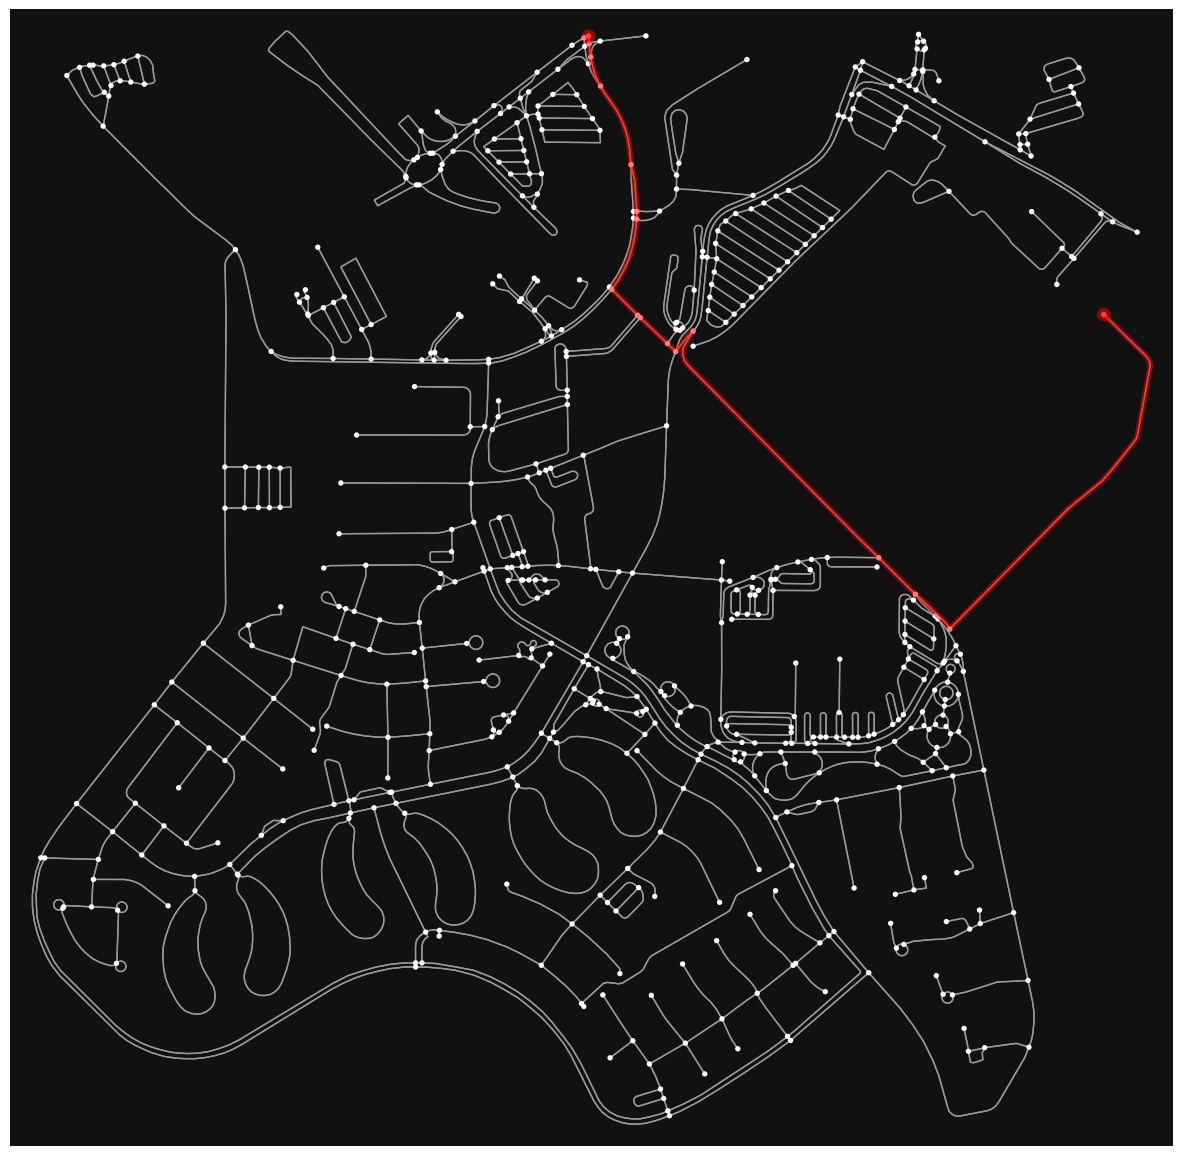

(<Figure size 1500x1500 with 1 Axes>, <Axes: >)

In [16]:
ox.plot_graph_route(graph,shortest_route,figsize=(15,15))

Let’s make a map that shows the above route, with both starting and ending nodes shown as markers using draw_route implemented as part of our Python package optalgotools.

In [ ]:
# !pip install optalgotools
from optalgotools import routing

routing.draw_route(graph, shortest_route)

***
## Gas Stations in Riyadh as an example

 Let's use a dataset of public locations, such as gas stations or landmarks in Saudi Arabia, which you can retrieve via OpenStreetMap's Overpass API.

In [20]:
import requests
import folium

# Define the location of Saudi Arabia (e.g., Riyadh)
lat, lon = 24.7136, 46.6753  # Coordinates for Riyadh, Saudi Arabia

# URL for Overpass API to fetch gas stations data in Saudi Arabia
overpass_url = "http://overpass-api.de/api/interpreter"
overpass_query = """
[out:json];
node["amenity"="fuel"](24.5,46.0,25.0,47.0);  // Bounding box for Riyadh area
out body;
"""

# Fetch the data from Overpass API
response = requests.get(overpass_url, params={'data': overpass_query})
data = response.json()

# Extract the gas station data from the JSON response
stations = []
for element in data['elements']:
    if 'lat' in element and 'lon' in element:
        stations.append({
            'station_id': element.get('id'),
            'name': element.get('tags', {}).get('name', 'Unknown'),
            'lat': element['lat'],
            'lon': element['lon'],
            'address': element.get('tags', {}).get('address', 'N/A'),
        })

# Create a folium map centered around Riyadh
saudi_map = folium.Map(location=[lat, lon], zoom_start=12)

# Add markers for each gas station
for station in stations:
    lat = station["lat"]
    lon = station["lon"]
    id = station["station_id"]
    name = station["name"]
    address = station["address"]

    # Create a marker and add it to the map
    folium.Marker(
        location=[lat, lon],
        popup=f"Id: {id}<br>Name: {name}<br>Address: {address}",
        icon=folium.Icon(color="red", icon="info-sign"),
    ).add_to(saudi_map)

# Display the map
saudi_map

📚 **For more information:** Please refer to this short article: [Handling Geospatial Data and Mapping in Python](https://medium.com/ai4sm/handling-geospatial-data-and-mapping-in-python-5e63326a13d5)